In [5]:
from neural_reconstruction.core.preprocessing import SkinAnalysisPipeline, PipelineConfig
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt



data_dir = "../data/S1585-2_a/"
image = np.array(Image.open(os.path.join(data_dir, "image.png")).convert("RGB"))[:,:, 1].astype(np.uint8)
mask = np.array(Image.open(os.path.join(data_dir, "mask.png"))).astype(np.uint8)
annotation = np.array(Image.open(os.path.join(data_dir, "annotation.png"))).astype(np.uint8)

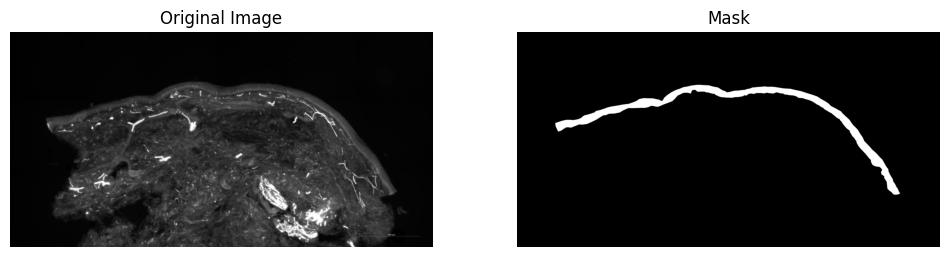

In [6]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

In [9]:
config = PipelineConfig()
config.morphology.closing_kernel = 0
config.threshold.use_full_roi = True
config.background.sato_weight = 0.3
config.normalization.method = "minmax"

pipeline = SkinAnalysisPipeline(config)

final_label, roi_image = pipeline.run(annotation, mask,image)

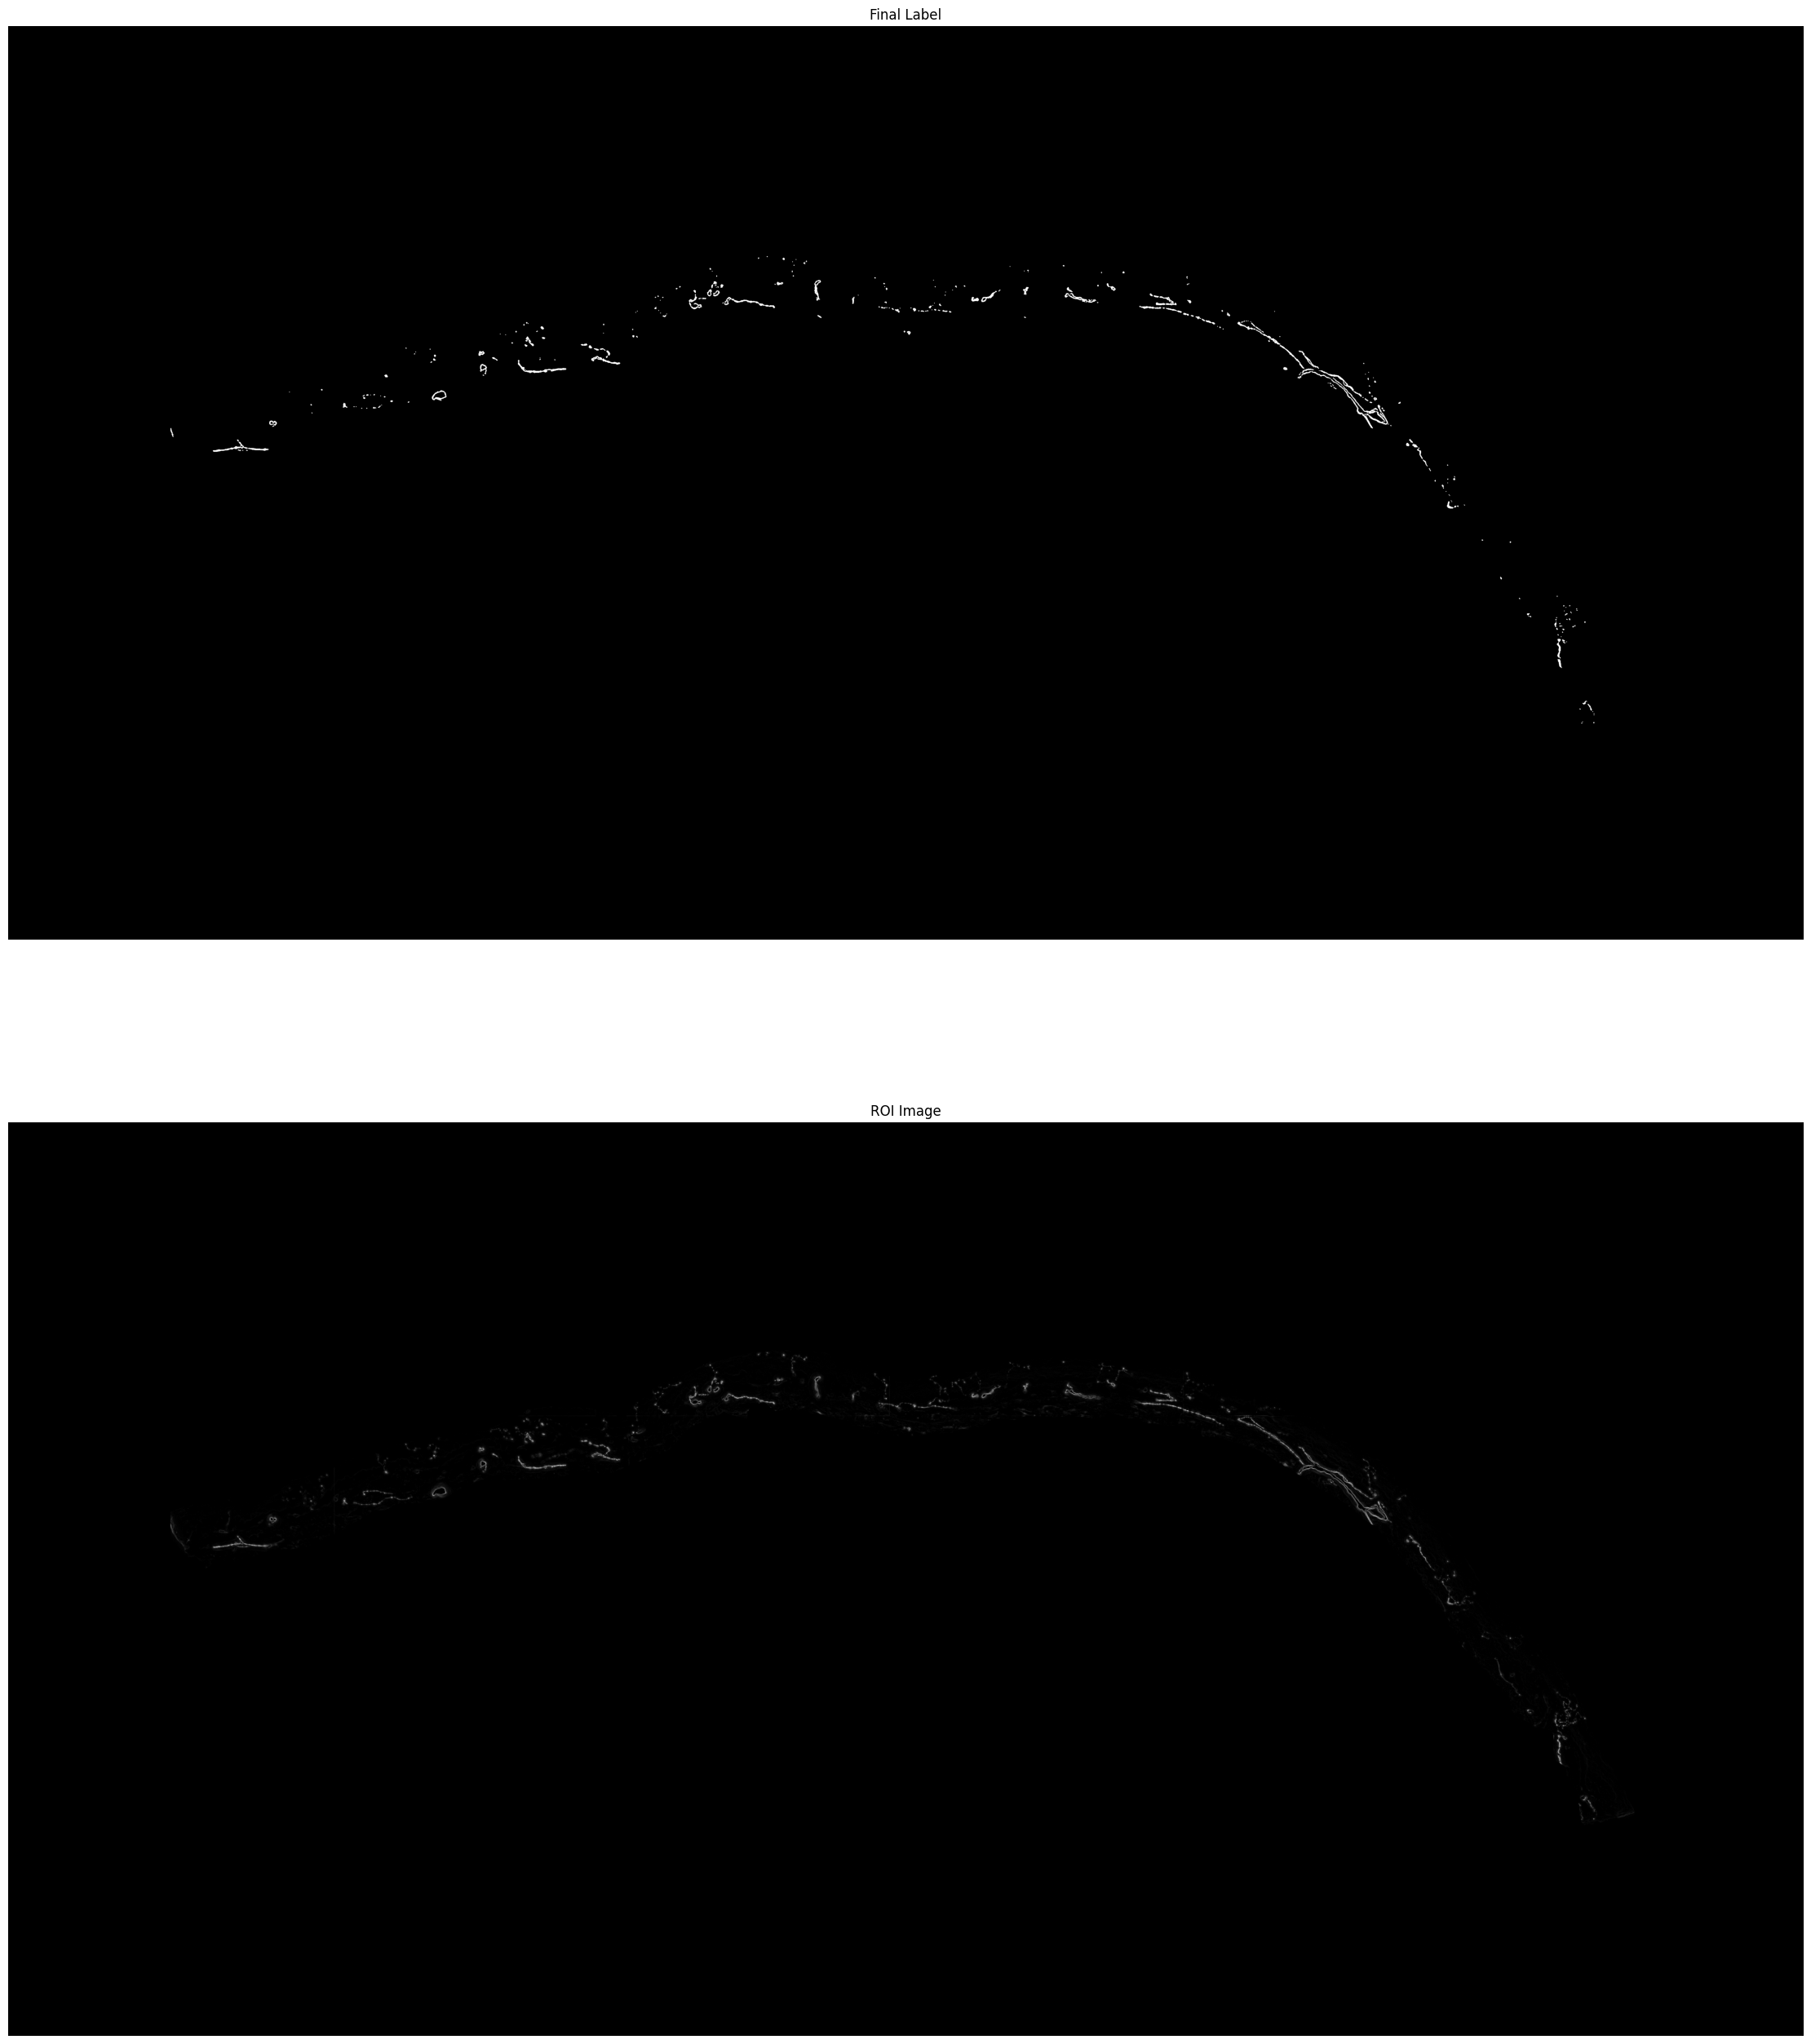

In [10]:
plt.figure(figsize=(64, 32))
plt.subplot(2, 1, 1)
plt.title("Final Label")
plt.imshow(final_label, cmap="gray")
plt.axis("off")
plt.subplot(2, 1, 2)
plt.title("ROI Image")
plt.imshow(roi_image, cmap="gray")
plt.axis("off")
plt.show()	